In [1]:
# IMPORTS
from pathlib import Path
from FuncionesAUX import *

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 

In [2]:
# ============================================================
# RUTAS DE TRABAJO
# ============================================================
BASE = Path(r"C:\Users\Gambo\Documents\Master Aaron\TFM UCM")
DATA = BASE / "Data"
FIGURES = BASE / "Figures"

ruta_firespain = DATA / "firespain025_WGS84.nc"
ruta_era5 = DATA / "era5" / "era5_land_clean.nc"
ruta_provincias = (DATA / "SHP_ETRS89" / "ll_provinciales_inspire_peninbal_etrs89" / "ll_provinciales_inspire_peninbal_etrs89.shp")
ruta_mdt = DATA / "MDT" / "mdt_025.nc"
ruta_civio = DATA / "CIVIO" / "civio_features.nc"

# CARGA DE ARCHIVOS

In [3]:
firespain = xr.open_dataset(ruta_firespain)
civio = xr.open_dataset(ruta_civio)
era5 = xr.open_dataset(ruta_era5)
mdt = xr.open_dataset(ruta_mdt)

datasets = {"FIRESPAIN": firespain, "ERA5": era5, "MDT": mdt, "CIVIO": civio}

print_header("CARGA DE DATASETS")
for nombre, ds in datasets.items():
    dims = dict(ds.sizes)
    print(f"\n{nombre}")
    print(f"  dims: {dims}")
    print(f"  vars: {list(ds.data_vars)}")


CARGA DE DATASETS

FIRESPAIN
  dims: {'time': 14245, 'latitude': 34, 'longitude': 54}
  vars: ['ba']

ERA5
  dims: {'time': 5115, 'latitude': 34, 'longitude': 54}
  vars: ['swvl1', 'swvl2', 't2m', 'tp', 'swi_T10_swvl1', 'swi_T10_swvl2', 'swi_T20_swvl1', 'swi_T20_swvl2', 'swi_T40_swvl1', 'swi_T40_swvl2']

MDT
  dims: {'latitude': 34, 'longitude': 54}
  vars: ['elevacion', 'pendiente']

CIVIO
  dims: {'latitude': 34, 'longitude': 54}
  vars: ['densidad_igniciones', 'pct_causa_antropica', 'pct_causa_rayo']


In [4]:
porcentaje_nulos = (mdt.isnull().mean() * 100).to_array().to_pandas()
print(porcentaje_nulos)

variable
elevacion    10.729847
pendiente    10.729847
dtype: float64


# COMPATIBILIDAD ESPACIAL

In [5]:
lat_ref = firespain.latitude.values
lon_ref = firespain.longitude.values

def verificar_rejilla(nombre, ds, lat_ref, lon_ref, tol=1e-6):
    lat_ok = ds.latitude.shape == lat_ref.shape and np.allclose(ds.latitude.values, lat_ref, atol=tol)
    lon_ok = ds.longitude.shape == lon_ref.shape and np.allclose(ds.longitude.values, lon_ref, atol=tol)

    lat_orden = "ascendente" if ds.latitude.values[0] < ds.latitude.values[-1] else "descendente"

    print(f"{nombre:12s} | lat idéntica: {str(lat_ok):5s} | lon idéntica: {str(lon_ok):5s} | orden lat: {lat_orden}")

    if not lat_ok:
        print(f"    lat {nombre}: min={ds.latitude.values.min():.4f} max={ds.latitude.values.max():.4f} "
              f"n={len(ds.latitude)}  vs ref n={len(lat_ref)}")
    if not lon_ok:
        print(f"    lon {nombre}: min={ds.longitude.values.min():.4f} max={ds.longitude.values.max():.4f} "
              f"n={len(ds.longitude)}  vs ref n={len(lon_ref)}")

    return lat_ok and lon_ok

print_header("VERIFICACIÓN DE REJILLAS (referencia = FIRESPAIN)")
print(f"Rejilla FIRESPAIN: {len(lat_ref)} x {len(lon_ref)}, "
      f"orden lat: {'ascendente' if lat_ref[0] < lat_ref[-1] else 'descendente'}")

resultados = {}
for nombre, ds in datasets.items():
    if nombre == "FIRESPAIN":
        continue
    resultados[nombre] = verificar_rejilla(nombre, ds, lat_ref, lon_ref)

if all(resultados.values()):
    print("Todas las rejillas coinciden exactamente con FIRESPAIN.")
else:
    print("Hay rejillas que NO coinciden")

VERIFICACIÓN DE REJILLAS (referencia = FIRESPAIN)
Rejilla FIRESPAIN: 34 x 54, orden lat: descendente
ERA5         | lat idéntica: True  | lon idéntica: True  | orden lat: descendente
MDT          | lat idéntica: True  | lon idéntica: True  | orden lat: descendente
CIVIO        | lat idéntica: True  | lon idéntica: True  | orden lat: descendente
Todas las rejillas coinciden exactamente con FIRESPAIN.


# COMPATIBILIDAD TEMPORAL

In [6]:
print_header("COBERTURA TEMPORAL")

for nombre in ["FIRESPAIN", "ERA5"]:
    ds = datasets[nombre]
    if "time" in ds.dims:
        t = ds.time.values
        print(f"{nombre:12s} | {pd.Timestamp(t.min()).date()} → {pd.Timestamp(t.max()).date()} "
              f"| n_pasos: {len(t)}")
    else:
        print(f"{nombre:12s} | sin dimensión temporal")

for nombre in ["MDT", "CIVIO"]:
    ds = datasets[nombre]
    print(f"{nombre:12s} | estático (sin eje 'time') — se espera que se repita para cada fecha en el merge")

COBERTURA TEMPORAL
FIRESPAIN    | 1983-01-02 → 2022-01-01 | n_pasos: 14245
ERA5         | 2008-01-01 → 2022-01-01 | n_pasos: 5115
MDT          | estático (sin eje 'time') — se espera que se repita para cada fecha en el merge
CIVIO        | estático (sin eje 'time') — se espera que se repita para cada fecha en el merge


## RECORTE TEMPORAL Y CONTROL DE CALIDAD

In [7]:
# ==============================================================================
# Objetivo: Garantizar la integridad física y la alineación con los predictores.
# ==============================================================================

fecha_ini = "2008-01-01"
fecha_fin = "2022-01-01"

fr_periodo = firespain.sel(time=slice(fecha_ini, fecha_fin))

print_header("TARGET — VERIFICACIÓN DEL RECORTE TEMPORAL")
print(f"Rango solicitado : desde {fecha_ini} hasta {fecha_fin}")
print(f"Rango recortado  : "
      f"desde {pd.Timestamp(fr_periodo.time.values.min()).date()} hasta "
      f"{pd.Timestamp(fr_periodo.time.values.max()).date()}")
print(f"N pasos temporales: {fr_periodo.sizes['time']}  "
      f"(ERA5 tiene {era5.sizes['time']} — deben coincidir)")

# CONTROL DE CONSISTENCIA TEMPORAL
assert fr_periodo.sizes["time"] == era5.sizes["time"], \
    "Descoincidencia de pasos temporales entre FIRESPAIN recortado y ERA5 — revisar fechas exactas"

TARGET — VERIFICACIÓN DEL RECORTE TEMPORAL
Rango solicitado : desde 2008-01-01 hasta 2022-01-01
Rango recortado  : desde 2008-01-01 hasta 2022-01-01
N pasos temporales: 5115  (ERA5 tiene 5115 — deben coincidir)


# EXPLORACIÓN DEL TARGET

MAGNITUD Y ESCASEZ (celda-día)
Observaciones totales válidas   : 4,338,436
Con ba = 0 (sin incendio)  : 4,242,678  (97.79%)
Con ba > 0 (con incendio)  : 95,758  (2.21%)

Estadísticos detallados de incendios activos (ba > 0):
count    95758.000000
mean        10.914261
std        177.350052
min          0.000100
50%          0.500000
90%         10.510000
95%         26.700001
99%        152.090303
99.9%     1113.486000
max      30691.390625
dtype: float64

Media   :    10.91 ha
Mediana :     0.50 ha
Máximo  : 30691.39 ha


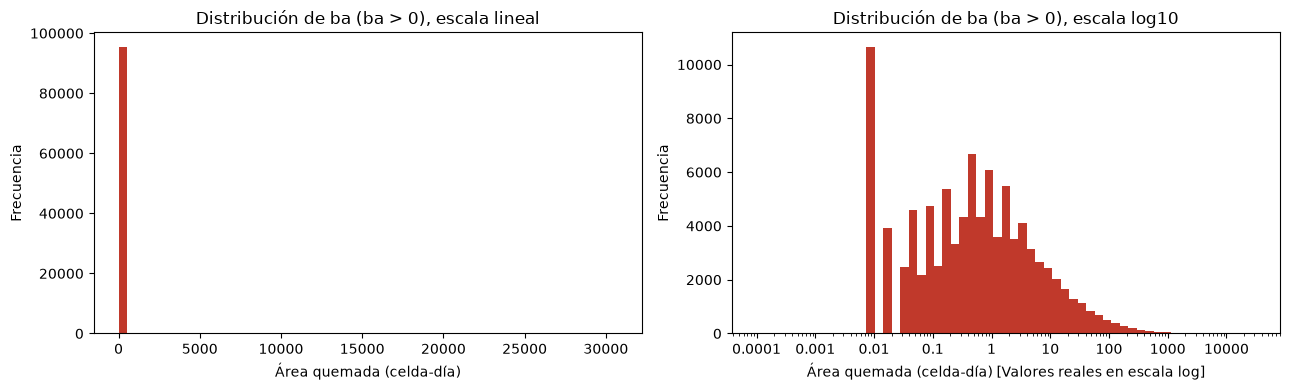

In [8]:
# ==============================================================================
# Objetivo: Comprender el comportamiento estadístico crudo a nivel celda-día.
# ==============================================================================

ba = fr_periodo["ba"]
ba_flat = ba.values.ravel()
ba_valid = ba_flat[~np.isnan(ba_flat)]
ba_positivos = ba_valid[ba_valid > 0]  # Corregido de 'positivos'

n_total = ba_valid.size
n_cero = (ba_valid == 0).sum()
n_positivo = ba_positivos.size

print_header("MAGNITUD Y ESCASEZ (celda-día)")
print(f"Observaciones totales válidas   : {n_total:,}")
print(f"Con ba = 0 (sin incendio)  : {n_cero:,}  ({100*n_cero/n_total:.2f}%)")
print(f"Con ba > 0 (con incendio)  : {n_positivo:,}  ({100*n_positivo/n_total:.2f}%)")
print(f"\nEstadísticos detallados de incendios activos (ba > 0):")
print(pd.Series(ba_positivos).describe(percentiles=[.5, .9, .95, .99, .999]))

print(f"\nMedia   : {ba_positivos.mean():8.2f} ha")
print(f"Mediana : {np.median(ba_positivos):8.2f} ha")
print(f"Máximo  : {ba_positivos.max():8.2f} ha")

# Visualización del sesgo brutal vs la distribución real oculta
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Subplot 2.1: Escala Lineal
axes[0].hist(ba_positivos, bins=60, color="#c0392b")
axes[0].set_title("Distribución de ba (ba > 0), escala lineal")
axes[0].set_xlabel("Área quemada (celda-día)")
axes[0].set_ylabel("Frecuencia")

# Subplot 2.2: Escala Log10 Optimizada
axes[1].hist(ba_positivos, bins=np.logspace(np.log10(ba_positivos.min()), np.log10(ba_positivos.max()), 60), color="#c0392b")
axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
axes[1].set_title("Distribución de ba (ba > 0), escala log10")
axes[1].set_xlabel("Área quemada (celda-día) [Valores reales en escala log]")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(FIGURES / "target_distribucion_magnitud.png", dpi=300, bbox_inches="tight")
plt.show()

# CONTEXTUALIZACIÓN TEMPORAL Y ESPACIAL

In [9]:
# ==============================================================================
# Objetivo: Analizar la dinámica macro de los datos antes de recortar o modelar.
# ==============================================================================

fechas = pd.to_datetime(fr_periodo.time.values)
ba_por_dia = ba.sum(dim=["latitude", "longitude"], skipna=True).values
df_temporal = pd.DataFrame({"fecha": fechas, "ba_total": ba_por_dia})
df_temporal["año"] = df_temporal["fecha"].dt.year

print_header("CONTEXTUALIZACIÓN HISTÓRICA Y GEOGRÁFICA")
ba_por_anio = df_temporal.groupby("año")["ba_total"].sum()
print("Área quemada total acumulada por año:")
print(ba_por_anio.to_string())

# Agregación espacial histórica para encontrar zonas críticas
ba_espacial = ba.sum(dim="time", skipna=True)
top_celdas = (ba_espacial.to_dataframe(name="ba_acumulada")
              .reset_index()
              .sort_values("ba_acumulada", ascending=False)
              .head(10)
              .round(3))
print("\nTop 10 celdas más afectadas históricamente:")
print(top_celdas.to_string(index=False))

CONTEXTUALIZACIÓN HISTÓRICA Y GEOGRÁFICA
Área quemada total acumulada por año:
año
2008     56249.449219
2009    133658.875000
2010     57871.378906
2011    107996.343750
2012    228042.656250
2013     71832.171875
2014     53784.421875
2015    128011.031250
2016     76244.046875
2017     80356.226562
2018     11167.308594
2019     23545.126953
2020     11059.350586
2021      5308.029785
2022         1.350000

Top 10 celdas más afectadas históricamente:
 latitude  longitude  ba_acumulada
   39.351     -0.885  30828.107422
   39.851     -0.885  23398.615234
   43.101     -3.635  18116.037109
   42.101     -6.885  17962.406250
   43.101     -6.635  15607.505859
   43.351     -6.635  15449.652344
   42.101     -6.135  14916.685547
   42.101     -0.885  14637.839844
   43.101     -3.885  14468.890625
   42.351     -6.635  13711.767578


## IMPACTO DE LA DEFINICIÓN DEL TARGET BINARIO

ESTRATEGIA DE MODELADO: ANÁLISIS DE UMBRALES
 Umbral (ha)  Positivos  Prevalencia (%)  Área capturada (%)
           0    4338436       100.000000          100.000000
           1      36983         0.852450           98.521240
           5      15898         0.366445           93.936584
          10      10103         0.232872           90.135887
          25       5065         0.116747           82.763153
          50       2841         0.065484           75.318596
         100       1469         0.033860           66.339371


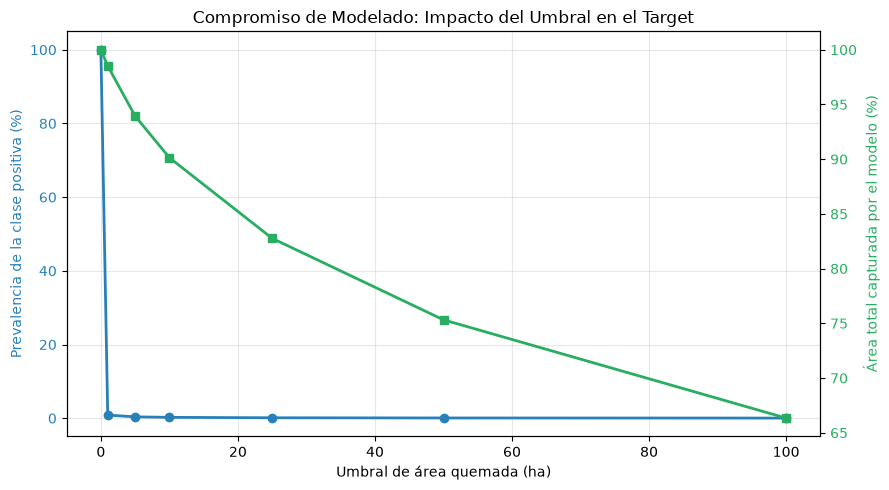

In [10]:
# ==============================================================================
# Objetivo: Evaluación entre sensibilidad del modelo y pérdida de datos.
# ==============================================================================
print_header("ESTRATEGIA DE MODELADO: ANÁLISIS DE UMBRALES")

umbrales = [0, 1, 5, 10, 25, 50, 100]
resultados = []
# Corregido: Se evalúa sobre el total de celdas válidas analizadas en el Paso 2
area_total_historica = ba_valid.sum() 

for u in umbrales:
    positivos_u = (ba_valid >= u).sum()
    prevalencia = (positivos_u / n_total) * 100
    area_capturada = ba_valid[ba_valid > u].sum()
    
    resultados.append({
        "Umbral (ha)": u,
        "Positivos": positivos_u,
        "Prevalencia (%)": prevalencia,
        "Área capturada (%)": 100 * area_capturada / area_total_historica
    })

df_umbral = pd.DataFrame(resultados)
print(df_umbral.to_string(index=False))

# Gráfico de impacto del umbral (Doble eje Y)
fig, ax1 = plt.subplots(figsize=(9, 5))

color_prev = "#2980b9"
ax1.plot(df_umbral["Umbral (ha)"], df_umbral["Prevalencia (%)"], 
         marker="o", linewidth=2, color=color_prev, label="Prevalencia")
ax1.set_xlabel("Umbral de área quemada (ha)")
ax1.set_ylabel("Prevalencia de la clase positiva (%)", color=color_prev)
ax1.tick_params(axis='y', labelcolor=color_prev)

ax2 = ax1.twinx()
color_area = "#27ae60"
ax2.plot(df_umbral["Umbral (ha)"], df_umbral["Área capturada (%)"], 
         marker="s", linewidth=2, color=color_area, label="Área Capturada")
ax2.set_ylabel("Área total capturada por el modelo (%)", color=color_area)
ax2.tick_params(axis='y', labelcolor=color_area)

ax1.set_title("Compromiso de Modelado: Impacto del Umbral en el Target")
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / "target_umbral.png", dpi=300, bbox_inches="tight")
plt.show()

## INSPECCIÓN DE LA COLA BAJA

ba <  0.0001 ha :       0 obs  (0.00% de los positivos)
ba <   0.001 ha :      17 obs  (0.02% de los positivos)
ba <    0.01 ha :     118 obs  (0.12% de los positivos)
ba <    0.05 ha :  18,911 obs  (19.75% de los positivos)
ba <     0.1 ha :  25,544 obs  (26.68% de los positivos)
ba <    0.25 ha :  38,043 obs  (39.73% de los positivos)
ba <     0.5 ha :  47,183 obs  (49.27% de los positivos)
ba <       1 ha :  58,775 obs  (61.38% de los positivos)


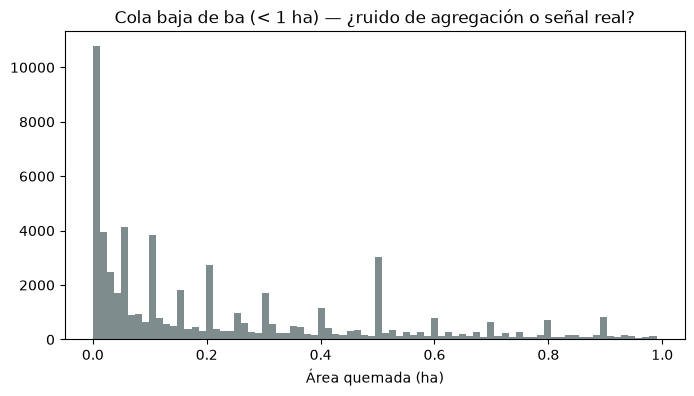

In [11]:
# ============================================================
# Objetivo: identificar si existe un "suelo" físico de
# detección por debajo del cual los valores son artefactos,
# no incendios reales.
# ============================================================

umbrales_finos = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1]
for u in umbrales_finos:
    n = (ba_positivos < u).sum()
    print(f"ba < {u:>7} ha : {n:>7,} obs  ({100*n/len(ba_positivos):.2f}% de los positivos)")

# Histograma solo de la cola muy baja (posible artefacto)
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(ba_positivos[ba_positivos < 1], bins=80, color="#7f8c8d")
ax.set_title("Cola baja de ba (< 1 ha) — ¿ruido de agregación o señal real?")
ax.set_xlabel("Área quemada (ha)")
plt.show()

# CONSTRUCCIÓN DE DATASET MAESTRO

 ## EXPANSIÓN DE VARIABLES ESTÁTICAS AL EJE TEMPORAL

In [12]:
# ============================================================
# Objetivo: Como MDT y CIVIO no tienen dimensión 'time'
# se repiten (broadcast) para cada paso temporal del 
# periodo de estudio (2008-2022)
# ============================================================

time_coord = fr_periodo.time
mdt_expandido = mdt.expand_dims(time=time_coord)
civio_expandido = civio.expand_dims(time=time_coord)

print("MDT expandido  :", dict(mdt_expandido.sizes))
print("CIVIO expandido:", dict(civio_expandido.sizes))

MDT expandido  : {'time': 5115, 'latitude': 34, 'longitude': 54}
CIVIO expandido: {'time': 5115, 'latitude': 34, 'longitude': 54}


# MARGE FINAL

In [13]:
# ============================================================
# Integración de todas las fuentes
# ============================================================

maestro = xr.merge([
    fr_periodo.rename({"ba": "target_ba"}),
    era5,
    mdt_expandido,
    civio_expandido
], join="exact")   # 'exact' fuerza a fallar si algo no coincide, en vez de rellenar con NaN silenciosamente

print_header("DATASET MAESTRO — RESUMEN")
print(maestro)

DATASET MAESTRO — RESUMEN
<xarray.Dataset> Size: 601MB
Dimensions:              (time: 5115, latitude: 34, longitude: 54)
Coordinates:
  * time                 (time) datetime64[ns] 41kB 2008-01-01 ... 2022-01-01
  * latitude             (latitude) float64 272B 43.6 43.35 43.1 ... 35.6 35.35
  * longitude            (longitude) float64 432B -9.135 -8.885 ... 3.865 4.115
Data variables: (12/16)
    target_ba            (time, latitude, longitude) float32 38MB nan ... nan
    swvl1                (time, latitude, longitude) float32 38MB ...
    swvl2                (time, latitude, longitude) float32 38MB ...
    t2m                  (time, latitude, longitude) float32 38MB ...
    tp                   (time, latitude, longitude) float32 38MB ...
    swi_T10_swvl1        (time, latitude, longitude) float32 38MB ...
    ...                   ...
    swi_T40_swvl2        (time, latitude, longitude) float32 38MB ...
    elevacion            (time, latitude, longitude) float32 38MB nan ... 6

## VERIFICACIÓN ESTRUCTURAL 

In [14]:
# Verificación de nulos por variable (antes de guardar) 
print_header("VERIFICACIÓN DE NULOS") 
for var in maestro.data_vars: 
    n_nan = np.isnan(maestro[var].values).sum() 
    pct = 100 * n_nan / maestro[var].size 
    print(f"{var:20s} NaN: {n_nan:>10,} ({pct:.3f}%)")

VERIFICACIÓN DE NULOS
target_ba            NaN:  5,052,704 (53.803%)
swvl1                NaN:  3,544,695 (37.745%)
swvl2                NaN:  3,544,695 (37.745%)
t2m                  NaN:  3,544,695 (37.745%)
tp                   NaN:  3,544,695 (37.745%)
swi_T10_swvl1        NaN:  3,544,695 (37.745%)
swi_T10_swvl2        NaN:  3,544,695 (37.745%)
swi_T20_swvl1        NaN:  3,544,695 (37.745%)
swi_T20_swvl2        NaN:  3,544,695 (37.745%)
swi_T40_swvl1        NaN:  3,544,695 (37.745%)
swi_T40_swvl2        NaN:  3,544,695 (37.745%)
elevacion            NaN:  1,007,655 (10.730%)
pendiente            NaN:  1,007,655 (10.730%)
densidad_igniciones  NaN:          0 (0.000%)
pct_causa_antropica  NaN:          0 (0.000%)
pct_causa_rayo       NaN:          0 (0.000%)


# DIAGNOSTICO DEL MARGE

## COBERTURA ESPACIAL POR FUENTE

COBERTURA ESPACIAL POR FUENTE (nº celdas válidas / 1836 totales)
target_ba (FIRESPAIN) : 965
ERA5-Land              : 1143
MDT (elevación)        : 1639


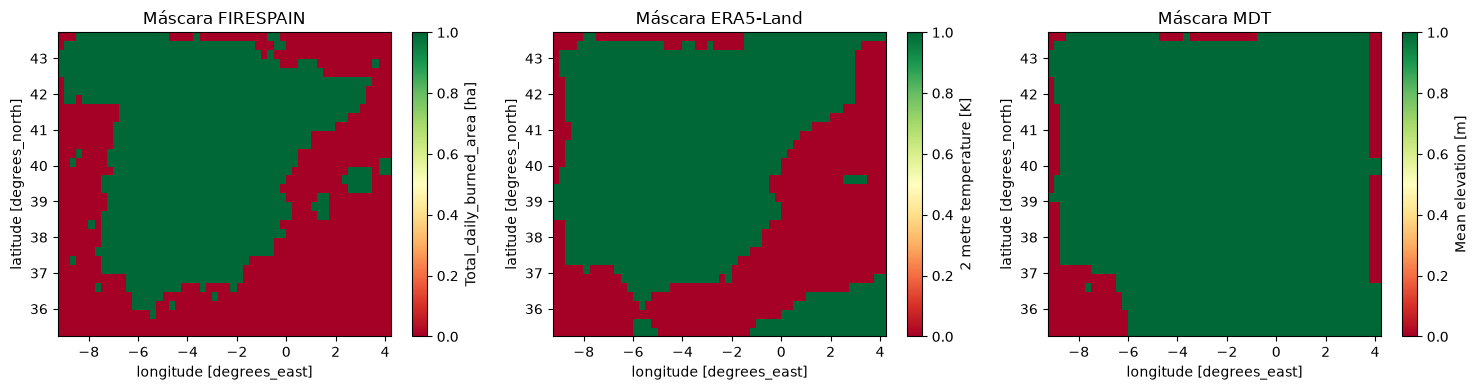


Celdas válidas en FIRESPAIN pero NO en ERA5-Land: 106
(valores >0 indican diferencias estructurales entre ambas máscaras)

Intersección de las 3 máscaras: 859 celdas de 1836
Eso supone 46.8% del dominio total


In [15]:
# ============================================================
# Objetivo: entender POR QUÉ difieren los NaN entre variables,
# antes de decidir cómo combinarlas.
# ============================================================

# Máscara espacial de cada fuente (colapsando el eje temporal
# cuando aplica — para ERA5/target_ba, "válido" = válido en
# CUALQUIER instante, ya que el land-sea mask no cambia con el tiempo)

mask_target = ~np.isnan(maestro["target_ba"]).all(dim="time")   # True = celda con algún dato válido
mask_era5   = ~np.isnan(maestro["t2m"]).all(dim="time")
mask_mdt    = ~np.isnan(maestro["elevacion"]).all(dim="time")

print_header("COBERTURA ESPACIAL POR FUENTE (nº celdas válidas / 1836 totales)")
print(f"target_ba (FIRESPAIN) : {int(mask_target.sum())}")
print(f"ERA5-Land              : {int(mask_era5.sum())}")
print(f"MDT (elevación)        : {int(mask_mdt.sum())}")

# Visualización comparativa de las tres máscaras
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mask_target.plot(ax=axes[0], cmap="RdYlGn"); axes[0].set_title("Máscara FIRESPAIN")
mask_era5.plot(ax=axes[1], cmap="RdYlGn");   axes[1].set_title("Máscara ERA5-Land")
mask_mdt.plot(ax=axes[2], cmap="RdYlGn");    axes[2].set_title("Máscara MDT")
plt.tight_layout()
plt.show()

# Solapamiento — ¿la máscara de FIRESPAIN está CONTENIDA en la de ERA5?
# (esperado si FIRESPAIN = subconjunto forestal de tierra firme)
solo_en_target_no_en_era5 = mask_target & ~mask_era5
print(f"\nCeldas válidas en FIRESPAIN pero NO en ERA5-Land: {int(solo_en_target_no_en_era5.sum())}")
print("(valores >0 indican diferencias estructurales entre ambas máscaras)")

interseccion = mask_target & mask_era5 & mask_mdt
print(f"\nIntersección de las 3 máscaras: {int(interseccion.sum())} celdas de 1836")
print(f"Eso supone {100*int(interseccion.sum())/1836:.1f}% del dominio total")

## VERIFICACIÓN EMPÍRICA DE CONTENCIÓN DE MÁSCARAS

In [16]:
# ============================================================
# Objetivo: confirmar (no asumir) que el dominio de FIRESPAIN
# está contenido en los dominios de ERA5 y MDT, antes de aplicar
# la máscara del target a todo el dataset maestro.
# ============================================================

mask_target = ~np.isnan(maestro["target_ba"]).all(dim="time")
mask_era5   = ~np.isnan(maestro["t2m"]).all(dim="time")
mask_mdt    = ~np.isnan(maestro["elevacion"]).all(dim="time")

n_dominio_target = int(mask_target.sum())

# Celdas donde FIRESPAIN es válido pero ERA5 o MDT NO lo son
fuera_era5 = mask_target & ~mask_era5
fuera_mdt  = mask_target & ~mask_mdt

print_header("CONTENCIÓN DE MÁSCARAS RESPECTO AL DOMINIO FIRESPAIN")
print(f"Celdas válidas en FIRESPAIN                    : {n_dominio_target}")
print(f"  ...de las cuales SIN dato ERA5-Land           : {int(fuera_era5.sum())}")
print(f"  ...de las cuales SIN dato MDT                 : {int(fuera_mdt.sum())}")

if fuera_era5.sum() > 0:
    print("\nCoordenadas con incendio potencial pero sin clima disponible:")
    print(maestro.latitude.where(fuera_era5, drop=True).values if fuera_era5.sum() < 20 else "múltiples celdas, revisar mapa")

if fuera_mdt.sum() > 0:
    print("\nCoordenadas con incendio potencial pero sin topografía disponible:")
    print(maestro.latitude.where(fuera_mdt, drop=True).values if fuera_mdt.sum() < 20 else "múltiples celdas, revisar mapa")

CONTENCIÓN DE MÁSCARAS RESPECTO AL DOMINIO FIRESPAIN
Celdas válidas en FIRESPAIN                    : 965
  ...de las cuales SIN dato ERA5-Land           : 106
  ...de las cuales SIN dato MDT                 : 0

Coordenadas con incendio potencial pero sin clima disponible:
múltiples celdas, revisar mapa


## LOCALIZACIÓN GEOGRÁFICA DE LAS CELDAS RESIDUALES

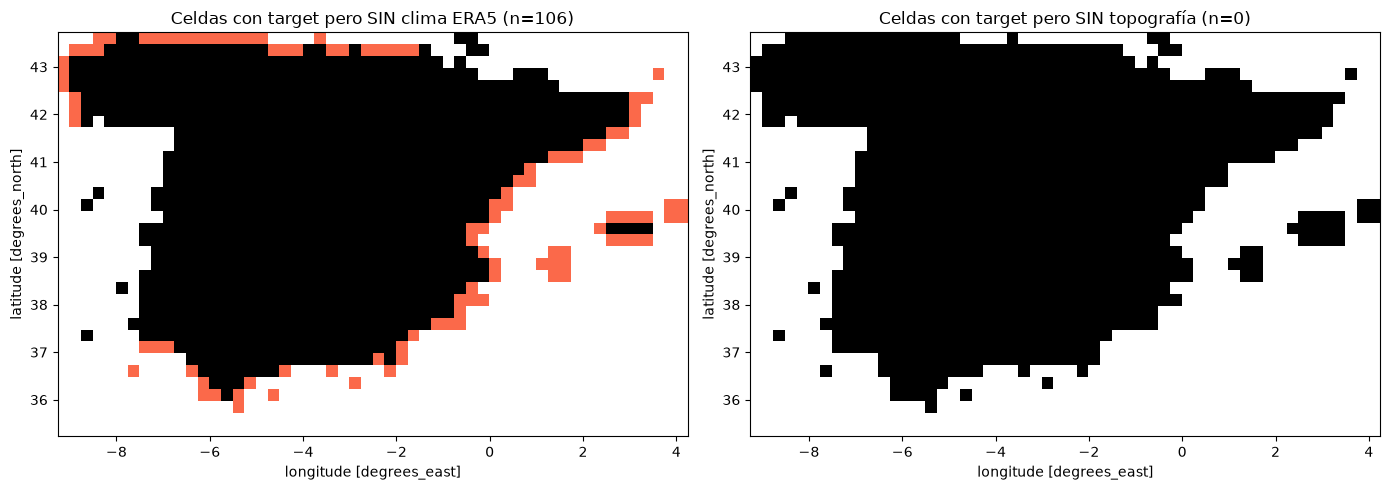

In [17]:
# ============================================================
# Objetivo: entender el patrón espacial antes de decidir la
# estrategia (imputar, descartar, o investigar más).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mapa 1: dominio FIRESPAIN completo, resaltando las celdas sin ERA5
mask_target.plot(ax=axes[0], cmap="Greys", add_colorbar=False)
fuera_era5.where(fuera_era5).plot(ax=axes[0], cmap="Reds", add_colorbar=False)
axes[0].set_title(f"Celdas con target pero SIN clima ERA5 (n={int(fuera_era5.sum())})")

# Mapa 2: dominio FIRESPAIN completo, resaltando las celdas sin MDT
mask_target.plot(ax=axes[1], cmap="Greys", add_colorbar=False)
fuera_mdt.where(fuera_mdt).plot(ax=axes[1], cmap="Blues", add_colorbar=False)
axes[1].set_title(f"Celdas con target pero SIN topografía (n={int(fuera_mdt.sum())})")

plt.tight_layout()
plt.savefig(FIGURES / "diagnostico_celdas_residuales.png", dpi=300)
plt.show()


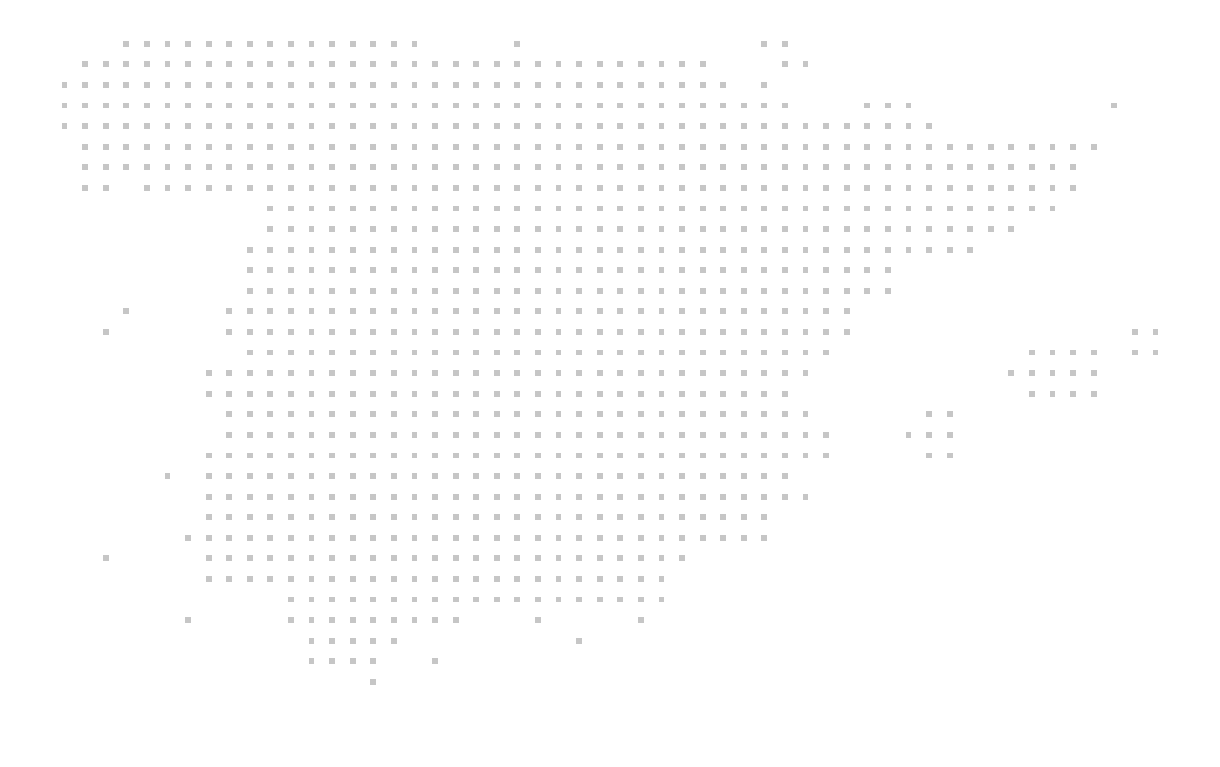

In [18]:
# Pasar de xarray a formato largo (lat, lon, valor)
df_dominio = mask_target.to_dataframe(name="valor").reset_index().dropna(subset=["valor"])

fig, ax = plt.subplots(figsize=(12, 12))

# Dominio completo en gris muy claro (silueta neutra)
ax.scatter(df_dominio["longitude"], df_dominio["latitude"],
           marker="s", s=18, c=df_dominio["valor"],
           cmap="Greys", vmin=0, vmax=3, linewidths=0)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout(pad=0)
plt.savefig(
    FIGURES / "video_celdas_residuales_scatter_firespain.png",
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

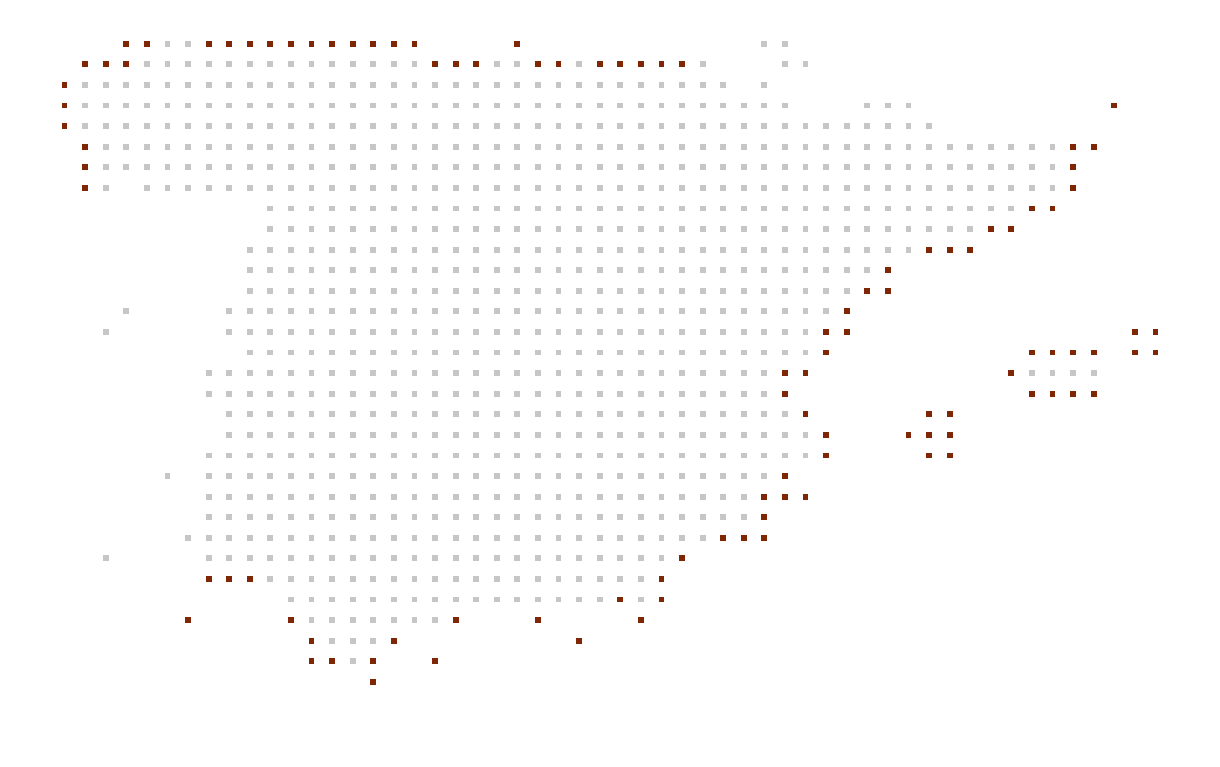

In [19]:

# Pasar de xarray a formato largo (lat, lon, valor)
df_dominio = mask_target.to_dataframe(name="valor").reset_index().dropna(subset=["valor"])
df_era5 = fuera_era5.where(fuera_era5).to_dataframe(name="valor").reset_index().dropna(subset=["valor"])

fig, ax = plt.subplots(figsize=(12, 12))

# Dominio completo en gris muy claro (silueta neutra)
ax.scatter(df_dominio["longitude"], df_dominio["latitude"],
           marker="s", s=18, c=df_dominio["valor"],
           cmap="Greys", vmin=0, vmax=3, linewidths=0)

# Celdas sin ERA5, resaltadas en naranja
ax.scatter(df_era5["longitude"], df_era5["latitude"],
           marker="s", s=18, c=df_era5["valor"],
           cmap="Oranges", vmin=0, vmax=0.6, linewidths=0)

ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout(pad=0)
plt.savefig(
    FIGURES / "video_celdas_residuales_scatter.png",
    dpi=300, bbox_inches="tight", transparent=True
)
plt.show()

## CUANTIFICACIÓN DEL IMPACTO DE LAS CELDAS RESIDUALES

In [20]:
# ============================================================
# Objetivo: decidir con datos si el descarte es trivial o si
# hay que documentarlo como pérdida de información relevante.
# ============================================================

celdas_a_excluir = fuera_era5 | fuera_mdt   # unión de ambos problemas
n_excluidas = int(celdas_a_excluir.sum())

# Área quemada acumulada en las celdas problemáticas vs el total del dominio FIRESPAIN
ba_total_dominio = maestro["target_ba"].where(mask_target).sum(skipna=True).item()
ba_en_excluidas = maestro["target_ba"].where(celdas_a_excluir).sum(skipna=True).item()

print_header("IMPACTO DE EXCLUIR LAS CELDAS RESIDUALES DEL DOMINIO")
print(f"Celdas excluidas (unión ERA5+MDT): {n_excluidas} de {n_dominio_target} "
      f"({100*n_excluidas/n_dominio_target:.1f}% del dominio FIRESPAIN)")
print(f"\nÁrea quemada total en el dominio FIRESPAIN : {ba_total_dominio:,.0f} ha")
print(f"Área quemada en celdas excluidas            : {ba_en_excluidas:,.0f} ha")
print(f"Porcentaje del área quemada total perdido   : {100*ba_en_excluidas/ba_total_dominio:.2f}%")

# Desglose: ¿cuánto corresponde a cada causa por separado?
ba_solo_era5 = maestro["target_ba"].where(fuera_era5).sum(skipna=True).item()
ba_solo_mdt  = maestro["target_ba"].where(fuera_mdt).sum(skipna=True).item()
print(f"\n  ...del cual por falta de ERA5 (limitación estructural): {ba_solo_era5:,.0f} ha")
print(f"  ...del cual por falta de MDT (artefacto de reproyección): {ba_solo_mdt:,.0f} ha")

IMPACTO DE EXCLUIR LAS CELDAS RESIDUALES DEL DOMINIO
Celdas excluidas (unión ERA5+MDT): 106 de 965 (11.0% del dominio FIRESPAIN)

Área quemada total en el dominio FIRESPAIN : 1,045,128 ha
Área quemada en celdas excluidas            : 53,916 ha
Porcentaje del área quemada total perdido   : 5.16%

  ...del cual por falta de ERA5 (limitación estructural): 53,916 ha
  ...del cual por falta de MDT (artefacto de reproyección): 0 ha


La comparación espacial de las máscaras mostró que las variables topográficas derivadas del MDT cubren completamente el dominio de FIRESPAIN tras el proceso de agregación espacial. En cambio, ERA5-Land presenta una menor cobertura en determinadas celdas costeras debido a diferencias entre las máscaras tierra-mar de ambos productos. Como consecuencia, el dominio final del conjunto de datos queda determinado por la intersección entre FIRESPAIN y ERA5-Land, descartándose un 11.0 % de las celdas espaciales originales, lo que supone únicamente el 5.16 % del área quemada acumulada del periodo de estudio.

In [21]:
print_header("DECISIÓN FINAL")
print(f"Celdas válidas FIRESPAIN : {n_dominio_target}")
print(f"Celdas excluidas         : {n_excluidas}")
print(f"Dominio final            : {n_dominio_target - n_excluidas}")
print(f"Área quemada conservada  : {100*(1-ba_en_excluidas/ba_total_dominio):.2f}%")

DECISIÓN FINAL
Celdas válidas FIRESPAIN : 965
Celdas excluidas         : 106
Dominio final            : 859
Área quemada conservada  : 94.84%


# DOMINIO FINAL DEL MODELO

In [22]:
# ============================================================
# Objetivo: aplicar el dominio verificado (859 celdas, 94.84% del
# área quemada conservada), construir el target binario definitivo
# y convertir a formato largo (una fila por celda-día).
# ============================================================

# Dominio final ya verificado
dominio_final = mask_target & ~celdas_a_excluir

print_header("DOMINIO FINAL — VERIFICACIÓN PREVIA A LA CONVERSIÓN")
print(f"Celdas en el dominio final: {int(dominio_final.sum())}  (esperado: 859)")

DOMINIO FINAL — VERIFICACIÓN PREVIA A LA CONVERSIÓN
Celdas en el dominio final: 859  (esperado: 859)


## CONSTRUCCIÓN DEL TARGET BINARIO

In [23]:
# ============================================================
# ba > 0 → 1 (incendio), ba == 0 o NaN → 0
# Decisión ya justificada: sin umbral de superficie mínima
# ============================================================

maestro["target_incendio"] = (maestro["target_ba"] > 0).astype(np.int8)

print(f"Target binario creado. Positivos totales (antes de aplicar dominio): "
      f"{int(maestro['target_incendio'].sum()):,}")

Target binario creado. Positivos totales (antes de aplicar dominio): 95,758


## CONVERSIÓN A FORMATO LARGO

In [24]:
# ============================================================
# No se usa .where(drop=True), porque el dominio final es un
# conjunto de celdas disperso, no un rectángulo geográfico, y
# ese método dejaría NaN residuales dentro del bounding box.
# ============================================================

# DataFrame de la máscara (sin eje temporal) para hacer el filtro
df_mask = dominio_final.to_dataframe(name="en_dominio").reset_index()

# DataFrame completo del maestro (esto es lo más pesado — puede tardar)
df_maestro = maestro.to_dataframe().reset_index()
print(f"Filas totales antes de filtrar por dominio: {len(df_maestro):,}")

# Merge por lat/lon para traer el flag de dominio a cada fila
df_maestro = df_maestro.merge(df_mask, on=["latitude", "longitude"], how="left")

# Filtrado final
df_final = df_maestro[df_maestro["en_dominio"]].drop(columns=["en_dominio"]).copy()
print(f"Filas tras aplicar dominio final: {len(df_final):,}")
print(f"Esperado (859 celdas × 5115 días): {859 * 5115:,}")

assert len(df_final) == 859 * 5115, "El número de filas no coincide con el esperado — revisar el merge"

Filas totales antes de filtrar por dominio: 9,391,140
Filas tras aplicar dominio final: 4,393,785
Esperado (859 celdas × 5115 días): 4,393,785


In [25]:
# ============================================================
# CONTROL DE CALIDAD FINAL
# ============================================================
print_header("CONTROL DE CALIDAD DEL DATASET FINAL")

# NaN residuales por columna (deberían ser 0 en todas tras aplicar el dominio)
nulos = df_final.isnull().sum()
nulos = nulos[nulos > 0]
if len(nulos) > 0:
    print("Columnas con NaN residuales dentro del dominio:")
    print(nulos)
else:
    print("Sin valores NaN dentro del dominio final.")

print(f"\nRango temporal : {df_final['time'].min()} → {df_final['time'].max()}")
print(f"Celdas únicas  : {df_final[['latitude','longitude']].drop_duplicates().shape[0]}")
print(f"Prevalencia target_incendio: {100*df_final['target_incendio'].mean():.4f}%")
print(f"\nTipos de datos:")
print(df_final.dtypes)

print(f"\nMemoria en RAM: {df_final.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nMuestra de filas:")
display(df_final.head(3))

CONTROL DE CALIDAD DEL DATASET FINAL
Columnas con NaN residuales dentro del dominio:
target_ba    212471
dtype: int64

Rango temporal : 2008-01-01 00:00:00 → 2022-01-01 00:00:00
Celdas únicas  : 859
Prevalencia target_incendio: 1.9916%

Tipos de datos:
time                   datetime64[ns]
latitude                      float64
longitude                     float64
target_ba                     float32
swvl1                         float32
swvl2                         float32
t2m                           float32
tp                            float32
swi_T10_swvl1                 float32
swi_T10_swvl2                 float32
swi_T20_swvl1                 float32
swi_T20_swvl2                 float32
swi_T40_swvl1                 float32
swi_T40_swvl2                 float32
elevacion                     float32
pendiente                     float32
densidad_igniciones             int32
pct_causa_antropica           float32
pct_causa_rayo                float32
target_incendio          

,time,latitude,longitude,target_ba,swvl1,swvl2,t2m,tp,swi_T10_swvl1,swi_T10_swvl2,swi_T20_swvl1,swi_T20_swvl2,swi_T40_swvl1,swi_T40_swvl2,elevacion,pendiente,densidad_igniciones,pct_causa_antropica,pct_causa_rayo,target_incendio
5,2008-01-01,43.601416,-7.885475,0.0,0.346635,0.348105,283.909943,4.351138e-07,0.346635,0.348105,0.346635,0.348105,0.346635,0.348105,496.654358,6.656644,471,1.000000,0.000000,0
6,2008-01-01,43.601416,-7.635475,0.0,0.422948,0.425451,283.470001,4.351138e-07,0.422948,0.425451,0.422948,0.425451,0.422948,0.425451,551.291504,5.636416,640,0.963636,0.036364,0
34,2008-01-01,43.601416,-0.635475,NaN,0.371342,0.374892,278.665771,4.351138e-07,0.371342,0.374892,0.371342,0.374892,0.371342,0.374892,102.190666,3.546487,0,0.000000,0.000000,0


In [26]:
# ============================================================
# DIAGNÓSTICO DE LOS NaN RESIDUALES EN target_ba
# Objetivo: entender el patrón antes de decidir cómo tratarlos.
# ============================================================

filas_nan_target = df_final[df_final["target_ba"].isnull()]

print_header("DIAGNÓSTICO — NaN RESIDUALES EN target_ba")
print(f"Total filas con target_ba NaN: {len(filas_nan_target):,} "
      f"({100*len(filas_nan_target)/len(df_final):.2f}% del dataset final)")

# ¿Se concentran en fechas concretas?
nan_por_fecha = filas_nan_target.groupby(filas_nan_target["time"].dt.date).size()
print(f"\nFechas afectadas: {nan_por_fecha.shape[0]} días distintos")
print(f"Máximo de celdas afectadas en un mismo día: {nan_por_fecha.max()}")
print(nan_por_fecha.sort_values(ascending=False).head(10))

# ¿Se concentran en celdas concretas?
nan_por_celda = filas_nan_target.groupby(["latitude", "longitude"]).size()
print(f"\nCeldas afectadas: {nan_por_celda.shape[0]} de 859")
print(f"Máximo de días afectados en una misma celda: {nan_por_celda.max()}")
print(nan_por_celda.sort_values(ascending=False).head(10))

# ¿Hay años concretos con más huecos? (posible cambio de cobertura del producto)
nan_por_anio = filas_nan_target.groupby(filas_nan_target["time"].dt.year).size()
print(f"\nDistribución por año:")
print(nan_por_anio)

DIAGNÓSTICO — NaN RESIDUALES EN target_ba
Total filas con target_ba NaN: 212,471 (4.84% del dataset final)

Fechas afectadas: 5115 días distintos
Máximo de celdas afectadas en un mismo día: 42
time
2008-01-10    42
2021-12-16    42
2022-01-01    42
2021-12-15    42
2008-01-02    42
2021-12-14    42
2008-01-04    42
2008-01-24    42
2008-01-23    42
2008-01-22    42
dtype: int64

Celdas afectadas: 42 de 859
Máximo de días afectados en una misma celda: 5114
latitude   longitude
37.351416  -8.635475    5114
38.101416  -7.385475    5114
38.601416  -7.385475    5114
38.351416  -7.885475    5114
43.601416  -0.385475    5114
           -0.635475    5114
42.851416   1.114525    5114
40.351416  -7.135475    5114
           -8.385475    5114
40.101416  -8.635475    5114
dtype: int64

Distribución por año:
time
2008    15157
2009    15007
2010    15112
2011    14970
2012    15076
2013    15109
2014    15219
2015    15086
2016    15220
2017    15188
2018    15263
2019    15326
2020    15371
2021  

NameError: name 'celdas_pobres' is not defined

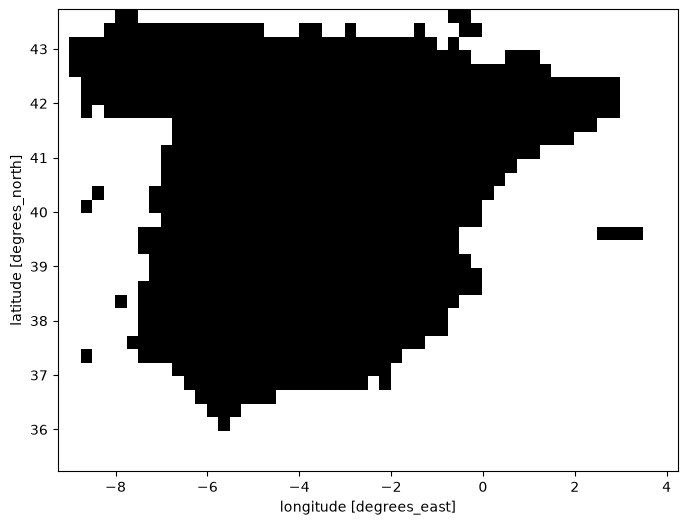

In [27]:
# Mapa de las 42 celdas excluidas por baja cobertura temporal
fig, ax = plt.subplots(figsize=(8, 6))

dominio_final.plot(ax=ax, cmap="Greys", add_colorbar=False)

celdas_pobres_da = xr.DataArray(
    np.zeros(dominio_final.shape, dtype=bool),
    coords=dominio_final.coords, dims=dominio_final.dims
)
for lat_c, lon_c in celdas_pobres[["latitude","longitude"]].values:
    celdas_pobres_da.loc[dict(latitude=lat_c, longitude=lon_c)] = True

celdas_pobres_da.where(celdas_pobres_da).plot(ax=ax, cmap="Reds", add_colorbar=False)
ax.set_title(f"Celdas excluidas por cobertura temporal <50% (n={len(celdas_pobres)})")
plt.savefig(FIGURES / "diagnostico_cobertura_temporal.png", dpi=300)

COBERTURA TEMPORAL POR CELDA
count    859.000000
mean      95.164283
std       21.346305
min        0.019550
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: pct_cobertura, dtype: float64


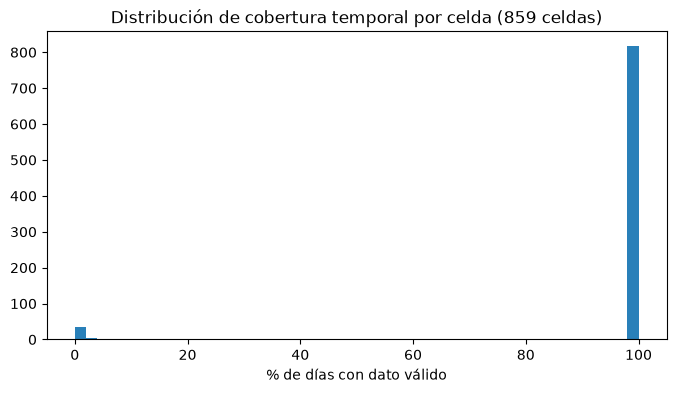


Celdas con menos del 50% de cobertura temporal: 42
      latitude  longitude  dias_con_dato  pct_cobertura
47   37.351416  -8.635475              1       0.019550
124  38.101416  -7.385475              1       0.019550
180  38.601416  -7.385475              1       0.019550
151  38.351416  -7.885475              1       0.019550
385  40.351416  -8.385475              1       0.019550
386  40.351416  -7.135475              1       0.019550
355  40.101416  -8.635475              1       0.019550
801  42.851416   1.114525              1       0.019550
857  43.601416  -0.635475              1       0.019550
858  43.601416  -0.385475              1       0.019550
853  43.351416  -0.385475              1       0.019550
834  43.101416  -0.635475              2       0.039101
71   37.601416  -7.635475              2       0.039101
356  40.101416  -7.135475              2       0.039101
798  42.851416  -0.385475              2       0.039101
152  38.351416  -7.385475              2       0.039

In [ ]:
# ============================================================
# DIAGNÓSTICO — CARACTERIZACIÓN COMPLETA DE LAS 42 CELDAS
# Objetivo: confirmar que son celdas casi vacías (no huecos
# parciales) antes de excluirlas del dominio.
# ============================================================

cobertura_por_celda = (
    df_final.groupby(["latitude", "longitude"])["target_ba"]
    .apply(lambda x: x.notna().sum())
    .rename("dias_con_dato")
    .reset_index()
)
cobertura_por_celda["pct_cobertura"] = 100 * cobertura_por_celda["dias_con_dato"] / 5115

print_header("COBERTURA TEMPORAL POR CELDA")
print(cobertura_por_celda["pct_cobertura"].describe())

# Histograma para ver si hay una separación clara entre
# celdas normales (~100% cobertura) y celdas casi vacías (~0%)
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(cobertura_por_celda["pct_cobertura"], bins=50, color="#2980b9")
ax.set_xlabel("% de días con dato válido")
ax.set_title("Distribución de cobertura temporal por celda (859 celdas)")
plt.show()

celdas_pobres = cobertura_por_celda[cobertura_por_celda["pct_cobertura"] < 50]
print(f"\nCeldas con menos del 50% de cobertura temporal: {len(celdas_pobres)}")
print(celdas_pobres.sort_values("pct_cobertura").head(45))

In [ ]:
# ============================================================
# EXCLUSIÓN DE CELDAS CON COBERTURA TEMPORAL INSUFICIENTE
# Se añade como tercer criterio de exclusión del dominio,
# junto a ERA5 (espacial) y MDT (ya resuelto en 02).
# Umbral: <50% de cobertura temporal → celda no utilizable.
# ============================================================

celdas_baja_cobertura = set(
    map(tuple, celdas_pobres[["latitude", "longitude"]].values)
)

df_final["clave_celda"] = list(zip(df_final["latitude"], df_final["longitude"]))
df_final_v2 = df_final[~df_final["clave_celda"].isin(celdas_baja_cobertura)].drop(columns=["clave_celda"])

print(f"Filas antes  : {len(df_final):,}")
print(f"Filas después: {len(df_final_v2):,}")
print(f"Celdas en dominio final definitivo: "
      f"{df_final_v2[['latitude','longitude']].drop_duplicates().shape[0]} (esperado: {859 - len(celdas_pobres)})")

# Verificación: ¿quedan NaN en target_ba tras excluir estas celdas?
n_nan_restante = df_final_v2["target_ba"].isnull().sum()
print(f"\nNaN residuales en target_ba tras exclusión: {n_nan_restante}")

Filas antes  : 4,393,785
Filas después: 4,178,955
Celdas en dominio final definitivo: 817 (esperado: 817)

NaN residuales en target_ba tras exclusión: 0


In [ ]:
# ============================================================
# IMPACTO FINAL EN ÁREA QUEMADA — incluyendo la exclusión
# por baja cobertura temporal (42 celdas fantasma)
# ============================================================

ba_total_original = df_final["target_ba"].sum(skipna=True)  # dominio de 859, antes de excluir las 42
ba_final = df_final_v2["target_ba"].sum(skipna=True)         # dominio definitivo de 817

print(f"Área quemada en dominio de 859 celdas : {ba_total_original:,.0f} ha")
print(f"Área quemada en dominio final (817)   : {ba_final:,.0f} ha")
print(f"Pérdida adicional por celdas fantasma : {ba_total_original - ba_final:,.0f} ha "
      f"({100*(ba_total_original-ba_final)/ba_total_original:.3f}%)")

# Cifra acumulada total desde el dominio FIRESPAIN original (965 celdas, 1.045.128 ha)
print(f"\nÁrea quemada conservada respecto al dominio FIRESPAIN original: "
      f"{100*ba_final/1_045_128:.2f}%")

Área quemada en dominio de 859 celdas : 991,212 ha
Área quemada en dominio final (817)   : 949,593 ha
Pérdida adicional por celdas fantasma : 41,619 ha (4.199%)

Área quemada conservada respecto al dominio FIRESPAIN original: 90.86%


In [ ]:
# ============================================================
# CONSOLIDACIÓN DEL DOMINIO DEFINITIVO
# df_final pasa a referirse al dominio final (817 celdas, sin NaN).
# La versión intermedia de 859 celdas queda descartada.
# ============================================================

df_final = df_final_v2.copy()
del df_final_v2  # evita cualquier referencia accidental a la versión anterior

print(f"df_final consolidado: {len(df_final):,} filas, "
      f"{df_final[['latitude','longitude']].drop_duplicates().shape[0]} celdas")
assert df_final["target_ba"].isnull().sum() == 0, "⚠ df_final todavía contiene NaN — revisar"

df_final consolidado: 4,178,955 filas, 817 celdas


In [ ]:
# ============================================================
# GUARDADO — dataset_maestro.parquet (dominio definitivo, 817 celdas)
# ============================================================

ruta_dataset_maestro = DATA / "dataset_maestro.parquet"

df_final["latitude"] = df_final["latitude"].astype(np.float32)
df_final["longitude"] = df_final["longitude"].astype(np.float32)

df_final.to_parquet(ruta_dataset_maestro, index=False, engine="pyarrow")

print_header("GUARDADO FINAL — DOMINIO DEFINITIVO")
print(f"Guardado en: {ruta_dataset_maestro}")
print(f"Tamaño en disco: {ruta_dataset_maestro.stat().st_size / 1e6:.1f} MB")
print(f"Filas: {len(df_final):,}  |  Columnas: {len(df_final.columns)}")
print(f"Celdas: 817  |  Prevalencia target_incendio: {100*df_final['target_incendio'].mean():.4f}%")

GUARDADO FINAL — DOMINIO DEFINITIVO
Guardado en: C:\Users\Gambo\Documents\Master Aaron\TFM UCM\Data\dataset_maestro.parquet
Tamaño en disco: 198.3 MB
Filas: 4,178,955  |  Columnas: 20
Celdas: 817  |  Prevalencia target_incendio: 2.0375%
